# Libraries

In [7]:
import time
import joblib
import pandas as pd
from functions import *
import matplotlib.pyplot as plt
import seaborn as sns

# Run g function

In [8]:
r_s_realization = np.array([[5, 2]])
n_latent_samples = 1000
times = list(np.linspace(0, 100, 100))
bds = []

In [9]:
for i in times:
    # Original function evaluation    
    start_counter_g = time.perf_counter()
    _, df = state_limit_function_time(r_s_realization, n_latent_samples=n_latent_samples, t=i)
    end_counter_g = time.perf_counter()
    g_list = df[0]['g'].to_list()

    # MLP metamodel evaluation
    start_counter_pce = time.perf_counter()
    mlp_i = joblib.load(r'D:\Documentos\ic_victor\toy_problem\ai_model\ann_model_lambda.joblib')
    x = pd.DataFrame({'R': list(r_s_realization[:,0]), 'S': list(r_s_realization[:,1]), 'Time': [i]})
    lambdass = mlp_i.predict(x)
    lambda_1 = lambdass[:, 0][0]
    lambda_2 = lambdass[:, 1][0]
    lambda_3 = 0.10
    lambda_4 = 0.10
    lambdass = [lambda_1, lambda_2, lambda_3, lambda_4]
    glam_g_list = glam_data_generator(lambdass, n_points=n_latent_samples)
    end_counter_pce = time.perf_counter()
    bd_obs = {"time": [i] * len(g_list), "g_obs": g_list, "g_emulator": glam_g_list, "elapsed time original": [end_counter_g - start_counter_g] * len(g_list), "elapsed time emulator": [end_counter_pce - start_counter_pce] * len(glam_g_list)}
    aux  = pd.DataFrame(bd_obs)
    bds.append(aux)

In [10]:
bds = pd.concat(bds, ignore_index=True)
bds


,time,g_obs,g_emulator,elapsed time original,elapsed time emulator
0,0.0,2.987252,2.178872,0.361469,0.005270
1,0.0,2.879091,2.237428,0.361469,0.005270
2,0.0,2.906727,2.273683,0.361469,0.005270
3,0.0,2.920304,2.300359,0.361469,0.005270
4,0.0,2.668893,2.321620,0.361469,0.005270
...,...,...,...,...,...
99995,100.0,-0.722311,-0.013098,0.360198,0.004022
99996,100.0,-0.854138,0.005089,0.360198,0.004022
99997,100.0,-1.052662,0.027909,0.360198,0.004022
99998,100.0,-0.472461,0.058923,0.360198,0.004022


In [11]:
bds.describe()

,time,g_obs,g_emulator,elapsed time original,elapsed time emulator
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.000000,1.253428,1.219899,0.497136,0.005709
std,29.157792,1.043586,1.097351,0.184906,0.001898
min,0.000000,-1.263963,-1.277094,0.266902,0.003697
25%,25.000000,0.363267,0.274879,0.338981,0.004022
50%,50.000000,1.248824,1.228490,0.387844,0.004723
75%,75.000000,2.134187,2.136667,0.701533,0.007737
max,100.000000,3.724371,3.842225,0.894919,0.010374


# Elapsed time analysis for g_obs

In [12]:
time_elapsed = bds['elapsed time original'].unique()
time_elapsed.sum()

49.713600699964445

# Elapsed time analysis for pce

In [13]:
time_elapsed_pce = bds['elapsed time emulator'].unique()
time_elapsed_pce.sum()

0.5709201999852667

# Charts - Compare real g and emulated g

In [14]:
df_summary = (
    bds
    .groupby("time")
    .agg(
        g_obs_mean=("g_obs", "mean"),
        g_emulator_mean=("g_emulator", "mean"),

    )
    .reset_index()
)
df_summary

,time,g_obs_mean,g_emulator_mean
0,0.000000,3.007316,2.989045
1,1.010101,2.977129,2.994966
2,2.020202,2.942894,3.013114
3,3.030303,2.891678,3.030593
4,4.040404,2.870186,3.032408
...,...,...,...
95,95.959596,-0.353602,-0.454265
96,96.969697,-0.386847,-0.486709
97,97.979798,-0.419981,-0.519152
98,98.989899,-0.461128,-0.551596


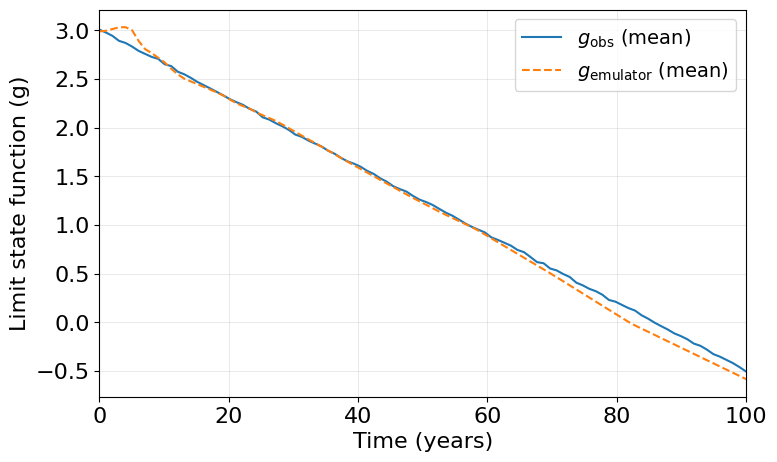

In [15]:
# =========================
# Figure name and DPI
# =========================
dpi = 600
name = 'g_mean_comparison'

# =========================
# Chart dimensions (cm → inches)
# =========================
b_cm = 20
h_cm = 12
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

# =========================
# Axis and labels
# =========================
label_x = 'Time (years)'
label_y = 'Limit state function (g)'
size_label = 16
color_label = 'black'
size_axis = 16
color_axis = 'black'

# =========================
# Line style
# =========================
size_line = 2
style_emulator = '--'

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(b_input, h_input))

# =========================
# Plot
# =========================
plt.plot(
    df_summary["time"],
    df_summary["g_obs_mean"],
    label=r'$g_{\mathrm{obs}}$ (mean)'
)

plt.plot(
    df_summary["time"],
    df_summary["g_emulator_mean"],
    linestyle='--',
    label=r'$g_{\mathrm{emulator}}$ (mean)'
)


# =========================
# Axis configuration
# =========================
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

ax.tick_params(axis='both', which='major',
               labelsize=size_axis, colors=color_axis)

ax.set_xlim(0, 100)

# =========================
# Grid (light background)
# =========================
ax.grid(
    True,
    which='both',
    linestyle='-',
    linewidth=0.4,
    color='gray',
    alpha=0.3
)

# =========================
# Legend
# =========================
ax.legend(fontsize=14)

# =========================
# Layout and save
# =========================
plt.tight_layout()
#fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()



# Remaining Useful Life (RUL) estimation

In [16]:
t_i = 35.0
g_threshold = 0.0

rul_data = rul(
    df_summary,
    t_i=35.0,
    g_threshold=0.0,
    g_column='g_emulator_mean'
)

print('Inspection time:', rul_data['t_inspection'])
print('Failure time:', rul_data['t_failure'])
print('RUL:', rul_data['RUL'])
print('g(t_i):', rul_data['g_at_inspection'])



Inspection time: 35.0
Failure time: 82.82828282828284
RUL: 47.82828282828284
g(t_i): 1.7793946419703912


In [17]:
# -------------------------
# Inputs
# -------------------------
t_i = 35.0
g_threshold = 0.0

# -------------------------
# RUL - Ground Truth
# -------------------------
rul_gt = rul(
    df_summary,
    t_i=t_i,
    g_threshold=g_threshold,
    g_column='g_obs_mean'
)

# -------------------------
# RUL - GLAM / ANN
# -------------------------
rul_glam = rul(
    df_summary,
    t_i=t_i,
    g_threshold=g_threshold,
    g_column='g_emulator_mean'
)

# -------------------------
# Resultados
# -------------------------
print('--- RUL COMPARISON ---')
print(f"Inspection time: {t_i:.1f} years\n")

print('Ground Truth:')
print(f"  Failure time = {rul_gt['t_failure']:.2f}")
print(f"  RUL_GT       = {rul_gt['RUL']:.2f}\n")

print('GLAM / ANN:')
print(f"  Failure time = {rul_glam['t_failure']:.2f}")
print(f"  RUL_GLAM     = {rul_glam['RUL']:.2f}\n")

# Diferença relativa
if not np.isnan(rul_gt['RUL']) and not np.isnan(rul_glam['RUL']):
    error = abs(rul_glam['RUL'] - rul_gt['RUL'])
    print(f"Absolute difference in RUL: {error:.2f} years")


--- RUL COMPARISON ---
Inspection time: 35.0 years

Ground Truth:
  Failure time = 85.86
  RUL_GT       = 50.86

GLAM / ANN:
  Failure time = 82.83
  RUL_GLAM     = 47.83

Absolute difference in RUL: 3.03 years


# RUL charts

### Limit State Function

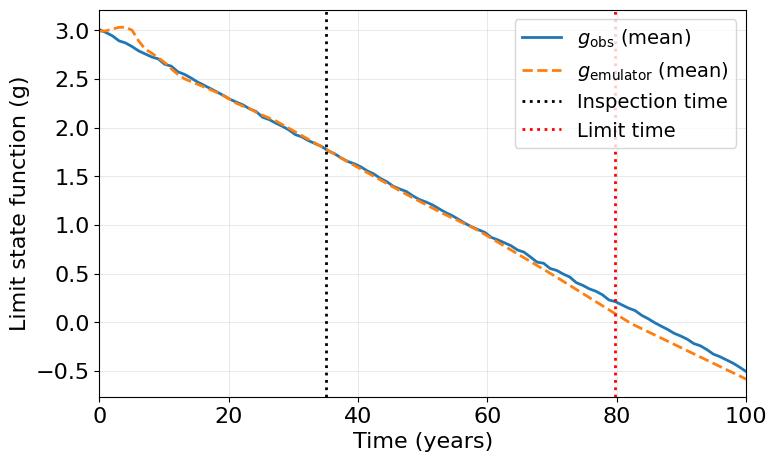

In [41]:
# =========================
# USER INPUT (Inspection scenario)
# =========================
t_i_user = 35     # Current inspection time (years)
t_limit_user = rul_data['t_failure']       # Limit time (years)

# =========================
# Figure name and DPI
# =========================
dpi = 600
name = 'g_mean_comparison_with_inspection'

# =========================
# Chart dimensions (cm → inches)
# =========================
b_cm = 20
h_cm = 12
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

# =========================
# Axis and labels
# =========================
label_x = 'Time (years)'
label_y = 'Limit state function (g)'
size_label = 16
color_label = 'black'
size_axis = 16
color_axis = 'black'

# =========================
# Line style
# =========================
size_line = 2
style_emulator = '--'

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(b_input, h_input))

# =========================
# Plot mean curves
# =========================
ax.plot(
    df_summary["time"],
    df_summary["g_obs_mean"],
    linewidth=size_line,
    label=r'$g_{\mathrm{obs}}$ (mean)'
)

ax.plot(
    df_summary["time"],
    df_summary["g_emulator_mean"],
    linewidth=size_line,
    linestyle=style_emulator,
    label=r'$g_{\mathrm{emulator}}$ (mean)'
)

# =========================
# Vertical markers (inspection & limit)
# =========================
ax.axvline(
    x=t_current,
    color='black',
    linestyle=':',
    linewidth=2,
    label='Inspection time'
)

ax.axvline(
    x=t_limit,
    color='red',
    linestyle=':',
    linewidth=2,
    label='Limit time'
)

# =========================
# Axis configuration
# =========================
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

ax.tick_params(axis='both', which='major',
               labelsize=size_axis, colors=color_axis)

ax.set_xlim(0, 100)

# =========================
# Grid (light background)
# =========================
ax.grid(
    True,
    which='both',
    linestyle='-',
    linewidth=0.4,
    color='gray',
    alpha=0.3
)

# =========================
# Legend
# =========================
ax.legend(fontsize=14)

# =========================
# Layout and save
# =========================
plt.tight_layout()
# fig.savefig(f'z_{name}_en.png', dpi=dpi, bbox_inches='tight')
plt.show()


### Probability density of g at t_i

In [ ]:
# =========================
# Select time in dataset
# =========================

t_i = nearest_time_in_dataset(bds, t_i_user)

print(f"User inspection time: {t_i_user}")
print(f"Used inspection time (nearest): {t_i}")

t_limit = nearest_time_in_dataset(bds, t_limit_user)

print(f"User inspection time: {t_limit_user}")
print(f"Used inspection time (nearest): {t_limit}")


g_inspection = g_emulator_at_inspect_time(
    bds,
    t_i=t_i,
    g_col="g_emulator"
)

g_limit = g_emulator_at_limit_time(
    bds,
    t_limit=t_limit,
    g_col="g_emulator"
)


User inspection time: 35
Used inspection time (nearest): 35.35353535353536
User inspection time: 82.82828282828284
Used inspection time (nearest): 82.82828282828284


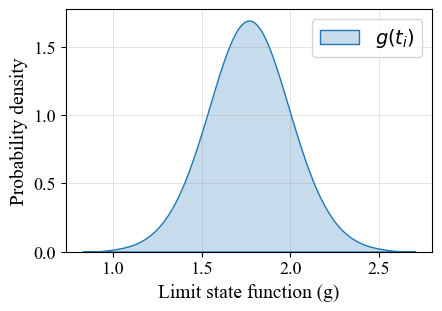

In [77]:
### Figure name and DPI
dpi = 600
name = 'kde_Probability density of g at t_i'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Labels
label_x = r'Limit state function (g)'
label_y = 'Probability density'
size_label = 14
color_label = 'black'
size_axis = 13
color_axis = 'black'

### Font configuration (Times New Roman)
plt.rcParams['font.family'] = 'Times New Roman'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)

### Plot KDE
sns.kdeplot(
    g_inspection,
    ax=ax,
    linewidth=1,
    fill=True,
    label=rf'$g(t_i)$'
)

### Grid
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='gray', alpha=0.3)

### Legend
ax.legend(fontsize=size_label)

### Title
# ax.set_title('KDE Plot', fontsize=16)

### Save
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()




### Probability density of g at t_limit

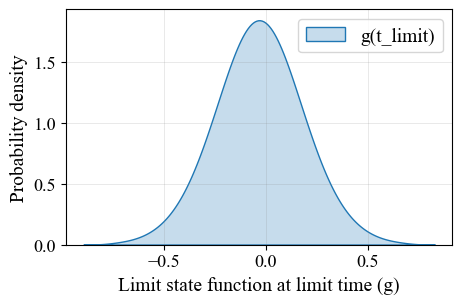

In [76]:
### Extract g at limit time
g_limit = g_emulator_at_limit_time(
    bds,
    t_limit=t_limit,
    g_col="g_emulator"
)

### Figure name and DPI
dpi = 600
name = 'kde_limit_plot'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Labels
label_x = r'Limit state function at limit time (g)'
label_y = 'Probability density'
size_label = 14
color_label = 'black'
size_axis = 13
color_axis = 'black'

### Font configuration (Times New Roman)
plt.rcParams['font.family'] = 'Times New Roman'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)

### KDE plot
sns.kdeplot(
    g_limit,
    ax=ax,
    linewidth=1,
    fill=True,
    label=r'g(t_limit)'
)

### Grid
ax.grid(True, linestyle='-', linewidth=0.4, color='gray', alpha=0.3)

### Legend
ax.legend(fontsize=size_label)

### Layout
plt.tight_layout()

### Save
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()


### Probability density of time to failure

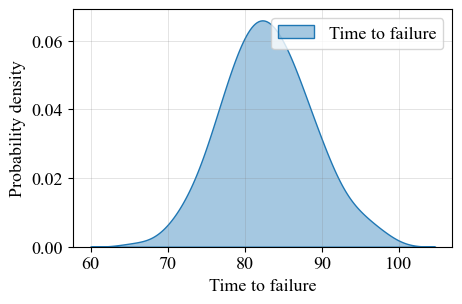

In [75]:
### Tolerance for g ≈ 0
g_tol = 0.005

### Select points where g ≈ 0
df_failure = bds.loc[
    np.abs(bds["g_emulator"]) <= g_tol,
    ["time", "g_emulator"]
].copy()

df_failure = df_failure.rename(columns={
    "time": "t_failure",
    "g_emulator": "g_failure"
})
df_failure.reset_index(drop=True, inplace=True)

### Figure name and DPI
dpi = 600
name = 'kde_time_to_failure'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Labels
label_x = "Time to failure"
label_y = "Probability density"
size_label = 13
color_label = 'black'
size_axis = 13
color_axis = 'black'

### Font configuration (Times New Roman)
plt.rcParams['font.family'] = 'Times New Roman'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)

### KDE plot
sns.kdeplot(
    df_failure["t_failure"],
    fill=True,
    linewidth=1,
    alpha=0.4,
    ax=ax,
    label="Time to failure"
)

### Grid
ax.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.3)

### Legend
ax.legend(fontsize=size_label)

### Layout
plt.tight_layout()

### Save
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()



### Probability density of RUL

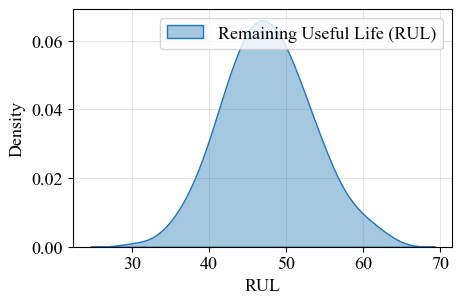

In [74]:
### Prepare RUL data
df_rul = df_failure.copy()
df_rul["RUL"] = df_rul["t_failure"] - t_i
df_rul = df_rul[df_rul["RUL"] >= 0]

### Figure name and DPI
dpi = 600
name = 'kde_rul'

### Chart dimensions (in centimeters)
b_cm = 12
h_cm = 8
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Labels
label_x = "RUL"
label_y = "Density"
size_label = 13
color_label = 'black'
size_axis = 13
color_axis = 'black'

### Font configuration (Times New Roman)
plt.rcParams['font.family'] = 'Times New Roman'

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)

### KDE plot
sns.kdeplot(
    df_rul["RUL"],
    fill=True,
    linewidth=1,
    alpha=0.4,
    ax=ax,
    label="Remaining Useful Life (RUL)"
)

### Grid
ax.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.3)

### Legend
ax.legend(fontsize=size_label)

### Layout
plt.tight_layout()

### Save
#fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()
